In [ ]:
!pip install grad-cam
!pip install scikit-image

In [9]:
import os

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from skimage import io
from skimage.transform import resize
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import KFold
from sklearn.preprocessing import label_binarize
from torch.utils.data import ConcatDataset, DataLoader, Dataset, Subset

# For GradCAM
#from pytorch_grad_cam import EigenCAM, GradCAM, FullGrad
#from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
#from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define image transformations
transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [11]:
class PotatoDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.classes = [
            d
            for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and not d.startswith(".")
        ]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.samples = []
        for class_name in self.classes:
            class_path = os.path.join(root, class_name)
            for fname in sorted(os.listdir(class_path)):
                if fname.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")
                ):
                    self.samples.append(
                        (os.path.join(class_path, fname), self.class_to_idx[class_name])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = io.imread(path)
        img = resize(img, (128, 128))  # Resize manually
        img = torch.tensor(img).permute(2, 0, 1)  # Convert to tensor (C, H, W)
        return img.float(), label

In [12]:
# Load datasets
dataset1_train = PotatoDataset("/workspace/potato_isr/Potato/Train", transform=transform)
dataset1_test = PotatoDataset("/workspace/potato_isr/Potato/Test", transform=transform)
dataset1_valid = PotatoDataset("/workspace/potato_isr/Potato/Valid", transform=transform)

dataset2_train = PotatoDataset("/workspace/potato_isr/PLD_3_Classes_256/Train", transform=transform)
dataset2_test = PotatoDataset("/workspace/potato_isr/PLD_3_Classes_256/Test", transform=transform)
dataset2_valid = PotatoDataset("/workspace/potato_isr/PLD_3_Classes_256/Valid", transform=transform)

# Load datasets with ISR
dataset1_isr_train = PotatoDataset("/workspace/potato_isr/Potato_ISR/Train", transform=transform)
dataset1_isr_test = PotatoDataset("/workspace/potato_isr/Potato_ISR/Test", transform=transform)
dataset1_isr_valid = PotatoDataset("/workspace/potato_isr/Potato_ISR/Valid", transform=transform)

dataset2_isr_train = PotatoDataset("/workspace/potato_isr/PLD_3_Classes_256_ISR/Train", transform=transform)
dataset2_isr_test = PotatoDataset("/workspace/potato_isr/PLD_3_Classes_256_ISR/Test", transform=transform)
dataset2_isr_valid = PotatoDataset("/workspace/potato_isr/PLD_3_Classes_256_ISR/Valid", transform=transform)

#datasets = {
#    "Plant Village": (dataset1_train, dataset1_test, dataset1_valid),
#    "Plant Village ISR": (dataset1_isr_train, dataset1_isr_test, dataset1_isr_valid),
#    "Kannauj Potato": (dataset2_train, dataset2_test, dataset2_valid),
#    "Kannauj Potato ISR": (dataset2_isr_train, dataset2_isr_test, dataset2_isr_valid),
#}

SWIN Transformer

In [13]:
# Define Swin Transformer model using conventional approach
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x


class SwinBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class SwinTransformer(nn.Module):
    def __init__(self, num_classes, embed_dim=96, num_heads=3, depth=2):
        super().__init__()
        self.patch_embed = PatchEmbedding()
        self.layers = nn.Sequential(
            *[SwinBlock(embed_dim, num_heads) for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.layers(x)
        x = self.norm(x.mean(dim=1))
        x = self.head(x)
        return x

Multiscale Channel Attention Transformer

In [14]:
# Define Multiscale Channel Attention Transformer model
class PatchEmbedding1(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x
        
class MultiScaleChannelAttention1(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(channels, channels // reduction, kernel_size=1)
        self.fc2 = nn.Conv2d(channels // reduction, channels, kernel_size=1)

    def forward(self, x):
        avg_out = self.fc2(F.relu(self.fc1(self.global_avg_pool(x))))
        max_out = self.fc2(F.relu(self.fc1(self.global_max_pool(x))))
        scale = torch.sigmoid(avg_out + max_out)
        return x * scale

class CNNBranch1(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=96):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, embed_dim, kernel_size=3, stride=1, padding=1)
        self.dwconv = nn.Conv2d(embed_dim, embed_dim, kernel_size=3, stride=1, padding=1, groups=embed_dim)
        self.msca = MultiScaleChannelAttention(embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.patch_size = patch_size

    def forward(self, x):
        x = self.conv1(x)
        x = self.dwconv(x)
        x = self.msca(x)
        B, C, H, W = x.shape
        x = x.view(B, C, -1).transpose(1, 2)  # Match Swin Transformer output shape
        x = self.norm(x)
        return x

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x

class MultiScaleChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(channels, channels // reduction, kernel_size=1)
        self.fc2 = nn.Conv2d(channels // reduction, channels, kernel_size=1)

    def forward(self, x):
        avg_out = self.fc2(F.relu(self.fc1(self.global_avg_pool(x))))
        max_out = self.fc2(F.relu(self.fc1(self.global_max_pool(x))))
        scale = torch.sigmoid(avg_out + max_out)
        return x * scale

class PixelAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, 1, kernel_size=1)  # Generate 1-channel attention map
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        attention_map = self.sigmoid(self.conv(x))  # Pixel-wise attention
        return x * attention_map  # Apply attention

class CNNBranch(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=96):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, embed_dim, kernel_size=3, stride=1, padding=1)
        self.dwconv = nn.Conv2d(embed_dim, embed_dim, kernel_size=3, stride=1, padding=1, groups=embed_dim)
        
        # Attention mechanisms
        self.msca = MultiScaleChannelAttention(embed_dim)
        self.pixel_attn = PixelAttention(embed_dim)

        self.norm = nn.LayerNorm(embed_dim)
        self.patch_size = patch_size

    def forward(self, x):
        x = self.conv1(x)
        x = self.dwconv(x)

        # Apply both attention modules in parallel
        msca_out = self.msca(x)
        pixel_out = self.pixel_attn(x)

        # Fuse outputs (element-wise sum)
        x = msca_out + pixel_out

        B, C, H, W = x.shape
        x = x.view(B, C, -1).transpose(1, 2)  # Match Swin Transformer output shape
        x = self.norm(x)
        return x
        
class SwinBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x
        
class SwinTransformerWithCNN(nn.Module):
    def __init__(self, num_classes, embed_dim=96, num_heads=3, depth=2, patch_size=4):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_size=patch_size, embed_dim=embed_dim)
        self.cnn_branch = CNNBranch(patch_size=patch_size, embed_dim=embed_dim)
        self.swin_layers = nn.Sequential(*[SwinBlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        swin_x = self.patch_embed(x)
        cnn_x = self.cnn_branch(x)
        if swin_x.shape != cnn_x.shape:
            min_seq_len = min(swin_x.shape[1], cnn_x.shape[1])
            swin_x = swin_x[:, :min_seq_len, :]
            cnn_x = cnn_x[:, :min_seq_len, :]
        x = swin_x + cnn_x  # Feature fusion
        x = self.swin_layers(x)
        x = self.norm(x.mean(dim=1))
        x = self.head(x)
        return x

In [15]:
# Define training function
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

In [16]:
def evaluate_model(model, val_loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0.0
    true_labels = []
    pred_probs = []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            total_loss += loss.item()

            probs = torch.softmax(output, dim=1)  
            preds = torch.argmax(probs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            true_labels.extend(labels.cpu().numpy())
            pred_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total

    return avg_loss, accuracy, true_labels, pred_probs

In [17]:
def train_with_cross_validation(model, datasets, k_folds, num_epochs, batch_size, learning_rate, device):
    os.makedirs(output_dir_loss, exist_ok=True)
    os.makedirs(output_dir_acc, exist_ok=True)

    # Initialize results dictionary
    results = {
        dataset_name: {
            "train_losses": [],
            "val_losses": [],
            "train_accuracies": [],
            "val_accuracies": [],
            "true_labels": [],
            "pred_probs": [],
            "class_names": datasets[dataset_name][3]  # Assuming 4th element has class names
        }
        for dataset_name in datasets.keys()
    }

    for dataset_name, (train_dataset, test_dataset, val_dataset, class_names) in datasets.items():
        print(f"Training on dataset: {dataset_name}")
        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

        for fold, (train_idx, val_idx) in enumerate(kf.split(train_dataset)):
            print(f"Fold {fold + 1}/{k_folds}")
            
            train_subset = Subset(train_dataset, train_idx)
            val_subset = Subset(train_dataset, val_idx)
            
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
            
            #model = model_class(num_classes=len(class_names)).to(device)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate)
            criterion = nn.CrossEntropyLoss()

            train_losses, val_losses = [], []
            train_accuracies, val_accuracies = [], []
            all_true_labels, all_pred_probs = [], []

            for epoch in range(num_epochs):
                model.train()
                train_loss, correct_train, total_train = 0, 0, 0

                for images, labels in train_loader:
                    images, labels = images.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    train_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    correct_train += (predicted == labels).sum().item()
                    total_train += labels.size(0)
                
                avg_train_loss = train_loss / len(train_loader)
                train_acc = correct_train / total_train * 100
                train_losses.append(avg_train_loss)
                train_accuracies.append(train_acc)

                model.eval()
                val_loss, correct_val, total_val = 0, 0, 0
                fold_true_labels, fold_pred_probs = [], []

                with torch.no_grad():
                    for images, labels in val_loader:
                        images, labels = images.to(device), labels.to(device)

                        outputs = model(images)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()

                        _, predicted = torch.max(outputs, 1)
                        correct_val += (predicted == labels).sum().item()
                        total_val += labels.size(0)

                        fold_true_labels.extend(labels.cpu().numpy())
                        fold_pred_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

                avg_val_loss = val_loss / len(val_loader)
                val_acc = correct_val / total_val * 100
                val_losses.append(avg_val_loss)
                val_accuracies.append(val_acc)

                print(f"Epoch {epoch + 1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.2f}% | Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.2f}%")

            # Store results
            results[dataset_name]["train_losses"].append(train_losses)
            results[dataset_name]["val_losses"].append(val_losses)
            results[dataset_name]["train_accuracies"].append(train_accuracies)
            results[dataset_name]["val_accuracies"].append(val_accuracies)
            results[dataset_name]["true_labels"].extend(fold_true_labels)
            results[dataset_name]["pred_probs"].extend(fold_pred_probs)

    return results


In [18]:
# 5-Fold Cross-Validation
num_epochs = 20
k_folds = 5
batch_size = 16
lr = 0.001
num_classes = 3

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_results = []

torch.manual_seed(42)

In [23]:
datasets = {
    "Plant Village": (dataset1_train, dataset1_test, dataset1_valid, dataset1_isr_train.classes),
    "Plant Village ISR": (dataset1_isr_train, dataset1_isr_test, dataset1_isr_valid, dataset1_isr_train.classes),
    "Kannauj Potato": (dataset2_train, dataset2_test, dataset2_valid, dataset2_train.classes),
    "Kannauj Potato ISR": (dataset2_isr_train, dataset2_isr_test, dataset2_isr_valid, dataset2_isr_train.classes),
}

model = SwinTransformerWithCNN(num_classes=num_classes).to(device)

output_dir_loss = "results/loss"
output_dir_acc = "results/accuracy"

In [24]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print the number of parameters
print(f"Number of parameters in SwinTransformer: {count_parameters(swin_model)}")
print(f"Number of parameters in SwinTransformerWithCNN: {count_parameters(swin_with_cnn_model)}")


Number of parameters in SwinTransformer: 325768
Number of parameters in SwinTransformerWithCNN: 330959


In [28]:
## Training Code ##
for dataset_name in datasets.keys():
    train_with_cross_validation(model, datasets, k_folds, num_epochs, batch_size, lr, device)

Training on dataset: Plant Village
Fold 1/3
Epoch 1: Train Loss = 0.6704, Train Acc = 67.67% | Val Loss = 0.6183, Val Acc = 74.67%
Epoch 2: Train Loss = 0.6076, Train Acc = 70.33% | Val Loss = 0.9540, Val Acc = 61.00%


KeyboardInterrupt: 

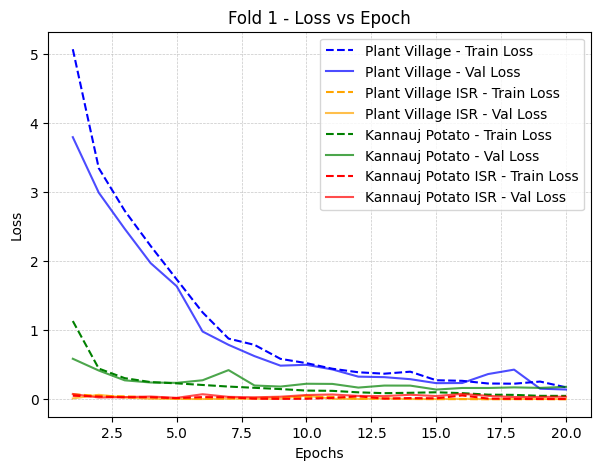

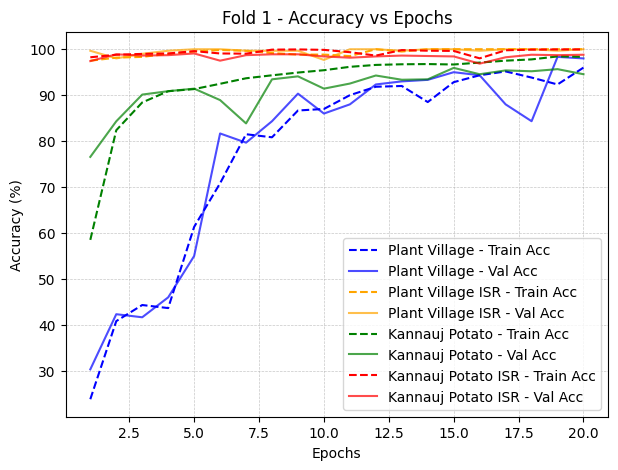

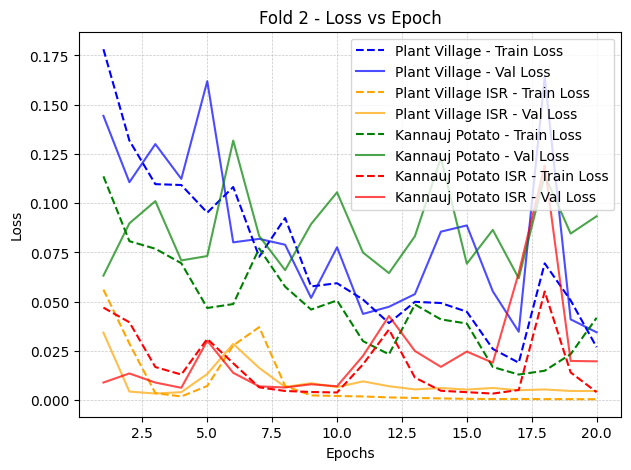

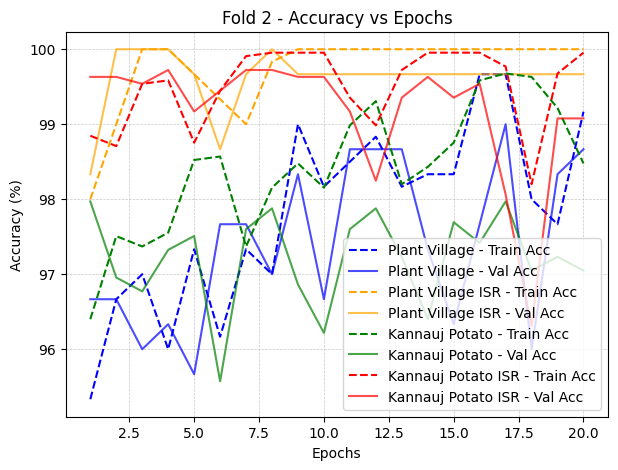

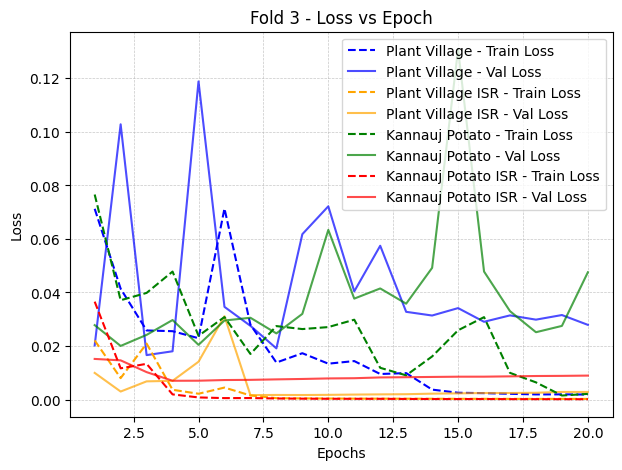

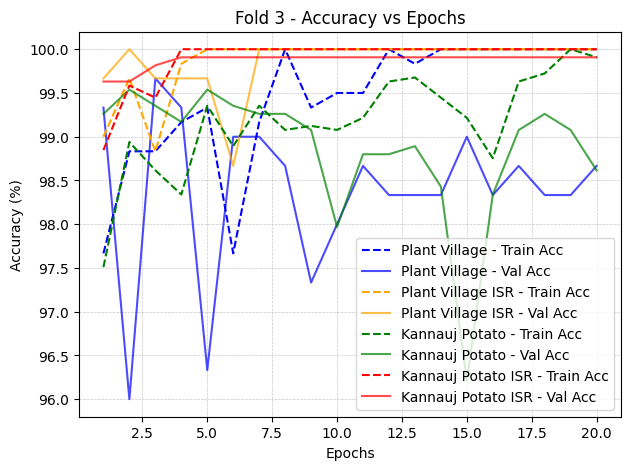

Loss curves saved in 'results/loss', Accuracy curves saved in 'results/accuracy'


In [14]:
def plot_curves_for_all_datasets(results, k_folds):
    loss_dir = "results/loss"
    acc_dir = "results/accuracy"
    os.makedirs(loss_dir, exist_ok=True)
    os.makedirs(acc_dir, exist_ok=True)

    result_keys = list(results.keys())  
    colors = ["blue", "orange", "green", "red"]  # Color per dataset

    for fold in range(k_folds):
        # Create **separate figures** for loss and accuracy
        fig_loss, ax_loss = plt.subplots(figsize=(7, 5))  # Separate loss plot
        fig_acc, ax_acc = plt.subplots(figsize=(7, 5))    # Separate accuracy plot

        ax_loss.set_title(f"Fold {fold+1} - Loss vs Epoch")
        ax_acc.set_title(f"Fold {fold+1} - Accuracy vs Epochs")

        for i, dataset in enumerate(result_keys):
            if dataset not in results or len(results[dataset]["train_losses"]) <= fold:
                print(f"Skipping {dataset} for Fold {fold+1} due to missing data.")
                continue

            # Extract loss values
            train_losses = results[dataset]["train_losses"][fold]
            val_losses = results[dataset]["val_losses"][fold]

            # Extract accuracy values
            train_accuracies = results[dataset]["train_accuracies"][fold]
            val_accuracies = results[dataset]["val_accuracies"][fold]

            # ✅ Plot losses
            ax_loss.plot(range(1, len(train_losses) + 1), train_losses, 
                         label=f"{dataset} - Train Loss", linestyle="--", color=colors[i])
            ax_loss.plot(range(1, len(val_losses) + 1), val_losses, 
                         label=f"{dataset} - Val Loss", color=colors[i], alpha=0.7)

            # ✅ Plot accuracies
            ax_acc.plot(range(1, len(train_accuracies) + 1), train_accuracies, 
                        label=f"{dataset} - Train Acc", linestyle="--", color=colors[i])
            ax_acc.plot(range(1, len(val_accuracies) + 1), val_accuracies, 
                        label=f"{dataset} - Val Acc", color=colors[i], alpha=0.7)

        # Configure Loss Plot
        ax_loss.set_xlabel("Epochs")
        ax_loss.set_ylabel("Loss")
        ax_loss.legend()
        ax_loss.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        loss_filename = os.path.join(loss_dir, f"loss_fold_{fold+1}.png")
        fig_loss.savefig(loss_filename, dpi=300, bbox_inches="tight")

        # Configure Accuracy Plot
        ax_acc.set_xlabel("Epochs")
        ax_acc.set_ylabel("Accuracy (%)")
        ax_acc.legend()
        ax_acc.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        acc_filename = os.path.join(acc_dir, f"accuracy_fold_{fold+1}.png")
        fig_acc.savefig(acc_filename, dpi=300, bbox_inches="tight")

        # Show the figures
        plt.show()

        # Close figures after saving to free memory
        plt.close(fig_loss)
        plt.close(fig_acc)

    print(f"Loss curves saved in '{loss_dir}', Accuracy curves saved in '{acc_dir}'")

# Run function
plot_curves_for_all_datasets(results, k_folds)


In [15]:
# Save the model Weight
torch.save(model.state_dict(), 'SwinTransformer_CNN_Block02_GT128.pth')

In [16]:
import pickle

# Save results to a file
with open("results.pkl", "wb") as f:
    pickle.dump(results, f)

# Load results later
with open("results.pkl", "rb") as f:
    loaded_results = pickle.load(f)


In [23]:
# Iterate over all datasets and generate classification reports
for dataset_name, data in results.items():
    if not data["true_labels"] or not data["pred_probs"]:
        print(f"Skipping {dataset_name} due to missing data.")
        continue

    # Extract true labels and predicted probabilities
    true_labels = np.array(data["true_labels"])
    pred_probs = np.array(data["pred_probs"])
    class_names = data["class_names"]

    # Convert probabilities to class predictions
    if pred_probs.shape[1] > 1:  # Multi-class classification
        pred_labels = np.argmax(pred_probs, axis=1)
    else:  # Binary classification (threshold at 0.5)
        pred_labels = (pred_probs > 0.5).astype(int)

    # Generate classification report
    report = classification_report(true_labels, pred_labels, target_names=class_names, digits=4)
    
    print(f"Classification Report for {dataset_name}:")
    print(report)
    print("=" * 80)

Classification Report for Plant Village:
              precision    recall  f1-score   support

Early_Blight     0.9802    0.9900    0.9851       300
     Healthy     0.9900    0.9867    0.9883       300
 Late_Blight     0.9832    0.9767    0.9799       300

    accuracy                         0.9844       900
   macro avg     0.9845    0.9844    0.9844       900
weighted avg     0.9845    0.9844    0.9844       900

Classification Report for Plant Village ISR:
              precision    recall  f1-score   support

Early_Blight     1.0000    1.0000    1.0000       300
     Healthy     0.9967    1.0000    0.9983       300
 Late_Blight     1.0000    0.9967    0.9983       300

    accuracy                         0.9989       900
   macro avg     0.9989    0.9989    0.9989       900
weighted avg     0.9989    0.9989    0.9989       900

Classification Report for Kannauj Potato:
              precision    recall  f1-score   support

Early_Blight     0.9533    0.9724    0.9628      1303
 

In [18]:
def plot_roc_curves(dataset_name, results):
    if dataset_name not in results:
        print(f"Dataset '{dataset_name}' not found in results.")
        return

    # Extract data
    true_labels = results[dataset_name].get("true_labels")
    pred_probs = np.array(results[dataset_name].get("pred_probs", []))
    class_names = results[dataset_name].get("class_names", [])

    if true_labels is None or len(true_labels) == 0 or pred_probs.size == 0:
        print(f"Skipping {dataset_name}: Missing true labels or prediction probabilities.")
        return

    num_classes = len(class_names)
    true_labels_bin = label_binarize(true_labels, classes=np.arange(num_classes))

    plt.figure(figsize=(8, 6))
    colors = ["blue", "red", "green", "orange", "purple"] * (num_classes // 5 + 1)

    for class_idx in range(num_classes):
        fpr, tpr, _ = roc_curve(true_labels_bin[:, class_idx], pred_probs[:, class_idx])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            color=colors[class_idx],
            lw=2,
            alpha=0.7,
            label=f"{class_names[class_idx]} (AUC={roc_auc:.2f})",
        )

    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{dataset_name} - Per-Class ROC Curves")
    plt.legend(loc="lower right")

    # Ensure directory exists
    save_dir = "roc_curves"
    os.makedirs(save_dir, exist_ok=True)

    # Save the figure
    filename = os.path.join(save_dir, f"{dataset_name.replace(' ', '_')}_roc_curve.png")
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.close()  # Close the plot to free memory

    print(f"Saved: {filename}")

# Example call:
plot_roc_curves("Plant Village", results)
plot_roc_curves("Plant Village ISR", results)
plot_roc_curves("Kannauj Potato", results)
plot_roc_curves("Kannauj Potato ISR", results)

Saved: roc_curves/Plant_Village_roc_curve.png
Saved: roc_curves/Plant_Village_ISR_roc_curve.png
Saved: roc_curves/Kannauj_Potato_roc_curve.png
Saved: roc_curves/Kannauj_Potato_ISR_roc_curve.png


In [19]:
def plot_confusion_matrix(dataset_name):
    if dataset_name not in results:
        print(f"Dataset '{dataset_name}' not found in results.")
        return

    # Extract Data
    true_labels = results[dataset_name]["true_labels"]
    pred_labels = np.argmax(np.array(results[dataset_name]["pred_probs"]), axis=1)
    class_names = results[dataset_name]["class_names"]

    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar()

    # Add labels to the plot
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    # Annotate each cell with the count
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{dataset_name} - Confusion Matrix")
    #plt.show()

    # Save the figure
    # Ensure directory exists
    save_dir = "confusion_matrices"
    os.makedirs(save_dir, exist_ok=True)

    # Save the figure
    filename = f"{save_dir}/{dataset_name.replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.close()  # Close the plot to free memory

    print(f"Saved: {filename}")

# Plot separately for each dataset
plot_confusion_matrix("Plant Village")
plot_confusion_matrix("Plant Village ISR")
plot_confusion_matrix("Kannauj Potato")
plot_confusion_matrix("Kannauj Potato ISR")


Saved: confusion_matrices/Plant_Village_confusion_matrix.png
Saved: confusion_matrices/Plant_Village_ISR_confusion_matrix.png
Saved: confusion_matrices/Kannauj_Potato_confusion_matrix.png
Saved: confusion_matrices/Kannauj_Potato_ISR_confusion_matrix.png


In [ ]:
# ✅ Updated Grad-CAM function with class names
def apply_gradcam(model, dataloader, target_layer, device, num_images=5, method="GradCAM"):
    """
    Applies Grad-CAM on a few images from the dataloader and plots results.
    
    method: "GradCAM", "EigenCAM", or "FullGrad"
    """
    model.eval()

    # ✅ Select appropriate CAM method
    cam_methods = {
        "GradCAM": GradCAM,
        "EigenCAM": EigenCAM,
        "FullGrad": FullGrad,
    }
    
    if method not in cam_methods:
        raise ValueError(f"Invalid method {method}. Choose from {list(cam_methods.keys())}")

    # ✅ Initialize CAM without 'use_cuda' (fixes TypeError)
    cam = cam_methods[method](model=model, target_layers=[target_layer])

    images, labels = next(iter(dataloader))  # Get a batch of images
    images, labels = images.to(device), labels.to(device)

    # ✅ Pick random images to visualize
    indices = np.random.choice(len(images), num_images, replace=False)

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        input_tensor = images[idx].unsqueeze(0).to(device)  # Ensure it's on the correct device
        targets = [ClassifierOutputTarget(labels[idx].item())]

        # ✅ Generate Grad-CAM heatmap
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        # ✅ Convert to numpy for visualization
        image_np = images[idx].permute(1, 2, 0).cpu().numpy()
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())  # Normalize to [0,1]

        heatmap = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

        # ✅ Plot with class names
        plt.subplot(1, num_images, i + 1)
        plt.imshow(heatmap)
        plt.axis("off")
        plt.title(f"{class_names[labels[idx].item()]}")  # ✅ Use class names

    plt.suptitle(f"{method} Visualization")
    plt.show()
    
# ✅ Loop through both datasets
for dataset_name, (train_dataset, test_dataset, valid_dataset) in datasets.items():
    print(f"\n🔹 Applying Grad-CAM for dataset: {dataset_name}")

    # ✅ Ensure class names exist in results
    if dataset_name not in results or "class_names" not in results[dataset_name]:
        raise KeyError(f"Class names not found for dataset '{dataset_name}' in results.")

    class_names = results[dataset_name]["class_names"]  # ✅ Use class names dynamically

    model.eval()  # Set model to evaluation mode

    # ✅ Choose a suitable target layer for Grad-CAM
    #target_layer = model.layers[-1].attn  # Last MultiheadAttention in final SwinBlock
    target_layer = [model.swin_layers[-1].attn, model.cnn_branch.msca]


    # ✅ Create DataLoader for test set
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

    # ✅ Apply Grad-CAM on test images
    apply_gradcam(model, test_loader, target_layer, device, method="FullGrad")


In [131]:
def apply_gradcam(model, dataloader, target_layer, device, num_images=5, method="GradCAM"):
    """
    Applies Grad-CAM on a few images from the dataloader and plots results.

    method: "GradCAM", "EigenCAM", or "FullGrad"
    """
    model.eval()

    cam_methods = {
        "GradCAM": GradCAM,
        "EigenCAM": EigenCAM,
        "FullGrad": FullGrad,
    }

    if method not in cam_methods:
        raise ValueError(f"Invalid method {method}. Choose from {list(cam_methods.keys())}")

    cam = cam_methods[method](model=model, target_layers=[target_layer])

    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    indices = np.random.choice(len(images), num_images, replace=False)

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        input_tensor = images[idx].unsqueeze(0).to(device)
        targets = [ClassifierOutputTarget(labels[idx].item())]

        # Correct GradCAM invocation
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        image_np = images[idx].permute(1, 2, 0).cpu().numpy()
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

        heatmap = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(heatmap)
        plt.axis("off")
        plt.title(f"{class_names[labels[idx].item()]}")

    plt.suptitle(f"{method} Visualization")
    plt.show()

In [132]:
method = "GradCAM"  # or "EigenCAM" / "FullGrad"

for dataset_name, dataset_values in datasets.items():
    print(f"\n🔹 Applying {method} for dataset: {dataset_name}")

    if dataset_name not in results or "class_names" not in results[dataset_name]:
        raise KeyError(f"Class names not found for dataset '{dataset_name}' in results.")

    class_names = results[dataset_name]["class_names"]

    model.eval()

    # ✅ Dynamically extract test dataset
    if isinstance(dataset_values, (tuple, list)) and len(dataset_values) >= 2:
        test_dataset = dataset_values[1]  # Assume second item is test dataset
    else:
        raise ValueError(f"Unexpected dataset structure for '{dataset_name}'. Expected at least 2 datasets.")

    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

    # ✅ Only pass target_layer for Grad-CAM or EigenCAM
    if method in ["GradCAM", "EigenCAM"]:
        target_layers = [model.swin_layers[-1].attn, model.cnn_branch.msca]
        for layer in target_layers:
            print(f"\n🔹 Applying {method} for layer: {layer}")
            apply_gradcam(model, test_loader, layer, device, method=method)

    # ✅ FullGrad is handled separately
    elif method == "FullGrad":
        print("\n🔹 Applying FullGrad (ignores target_layers)")
        apply_gradcam(model, test_loader, None, device, method="FullGrad")



🔹 Applying GradCAM for dataset: Plant Village

🔹 Applying GradCAM for layer: MultiheadAttention(
  (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
)


TypeError: 'GradCAM' object is not callable

<Figure size 1500x500 with 0 Axes>